# Building an Early-Warning System for Student Retention

## 1. Introduction
This dataset was originally compiled to identify higher education students at risk of dropping out so that support strategies could be deployed in advance. 

In its raw form, the target variable contains three classes: `Graduate`, `Dropout`, and `Enrolled`. `Enrolled` is not a final outcome; it is a transient state. An enrolled student today could graduate next year, or they could drop out tomorrow. Forcing a machine learning algorithm to find a static mathematical pattern for a temporary state would confuse the model and degrade performance.

To translate this academic dataset into a practical Early Intervention System, I made two strategic architecture decisions:
1. **Isolating the Historical Truth:** I split the data to isolate students whose outcomes are permanently sealed (`Graduate` and `Dropout`). I will train a binary classification model exclusively on this historical cohort to capture the pure mathematical signal of student attrition. 
2. **Probability Scoring for Live Deployment:** I will treat the `Enrolled` cohort as a live deployment set. Instead of predicting a hard "Yes/No", the model will calculate a Dropout Risk Probability for every currently enrolled student.

In [ ]:
# Import necessary libraries for data manipulation, visualization, and machine learning pipelines.
import pandas as pd
import numpy as np

from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, balanced_accuracy_score, recall_score
from sklearn.compose import ColumnTransformer

# Suppress warnings to maintain a clean notebook output for the final report.
import warnings
warnings.filterwarnings('ignore')

# Set a consistent, clean visual style for all upcoming plots.
sns.set_theme(style="whitegrid")

# Load the student attrition dataset and verify its initial dimensions.
df = pd.read_csv('data.csv', sep=';')

# Raw data preview.
display(df.head().style.set_caption(f"ORIGINAL DATASET SHAPE: {df.shape[0]} ROWS AND {df.shape[1]} COLUMNS"))

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.000000,1,19,12,5,9,127.300000,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.800000,1.400000,1.740000,Dropout
1,1,15,1,9254,1,1,160.000000,1,1,3,3,3,142.500000,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.900000,-0.300000,0.790000,Graduate
2,1,1,5,9070,1,1,122.000000,1,37,37,9,9,124.800000,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.800000,1.400000,1.740000,Dropout
3,1,17,2,9773,1,1,122.000000,1,38,37,5,3,119.600000,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.400000,-0.800000,-3.120000,Graduate
4,2,39,1,8014,0,1,100.000000,1,37,38,9,9,141.500000,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.900000,-0.300000,0.790000,Graduate


## 2. Justifying the Early Intervention Architecture
Before engineering my features, I need to determine what mathematically drives a student to drop out using the complete dataset (both 1st and 2nd semesters). By running a quick correlation analysis on the full historical cohort, I can see exactly which features are the strongest predictors of student outcomes.

In [2]:
# Standardize column names to snake_case to prevent referencing errors during analysis.
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('(', '')
    .str.replace(')', '')
    .str.replace('\t', '')
)

# Isolate the historical cohort (students with final outcomes) to evaluate full-year feature correlations.
df_full_historical = df[df['target'].isin(['Graduate', 'Dropout'])].copy()

# Convert the target outcomes into a binary numeric format to enable correlation calculations.
df_full_historical['target_num'] = df_full_historical['target'].replace({'Dropout': 1, 'Graduate': 0})

# Calculate the correlation of all numeric features against student attrition to identify the strongest indicators.
full_corr = df_full_historical.corr(numeric_only=True)['target_num'].sort_values()

# Display the findings to justify our feature selection strategy.
# Top retention predictors.
display(full_corr.head(4).to_frame(name='Correlation to Attrition').style.set_caption("FULL DATASET: TOP PREDICTORS OF RETENTION"))
# Top dropout predictors.
display(full_corr.dropna().tail(5).head(4).to_frame(name='Correlation to Attrition').style.set_caption("FULL DATASET: TOP PREDICTORS OF DROPPING OUT"))

,Correlation to Attrition
curricular_units_2nd_sem_approved,-0.653995
curricular_units_2nd_sem_grade,-0.605350
curricular_units_1st_sem_approved,-0.554881
curricular_units_1st_sem_grade,-0.519927


,Correlation to Attrition
application_mode,0.244507
gender,0.251955
debtor,0.267207
age_at_enrollment,0.267229


**The Trade-Off:** The data revealed that 2nd-semester grades are the strongest predictors of retention. This presents a choice. I could build a highly accurate model using end-of-year data, but that model could not be run until May. By that time, many struggling students will have already dropped out. 

To create an actionable Early Intervention System, I acknowledge the predictive power of 2nd-semester data but deliberately discard it. Restricting my model to 1st-semester data costs a slight amount of accuracy, but it buys the university a significant operational advantage: a 5-month head start to intervene in December.

## 3. Data Engineering: Building the December Deployment Pipeline
As proven in the previous step, 2nd-semester academic performance contains the strongest mathematical signals for predicting student attrition. To enforce the mid-year operational constraint, I am dropping those features entirely. 

Because `Enrolled` is a transient state, I also must isolate the historical ground truth from the active student body. My data engineering pipeline executes three steps:
1. **Drop Late-Stage Features:** Remove all 2nd-semester data.
2. **Isolate Historical Outcomes:** Split the dataset into a historical training cohort (`Graduate` and `Dropout`) and a live deployment cohort (`Enrolled`).
3. **Engineer the Target Variable:** Convert the historical target into a numeric binary classification (1 = `Dropout`, 0 = `Graduate`). By assigning `Dropout` as the positive class, the model is mathematically configured to output a direct "Risk Probability" score.

In [11]:
# Remove all second-semester data to simulate an early-warning deployment at the end of the first semester.
cols_to_drop = [col for col in df.columns if '2nd_sem' in col]
df = df.drop(columns=cols_to_drop)

# Separate the dataset into a historical training cohort and a live deployment cohort of currently enrolled students.
df_historical = df[df['target'].isin(['Graduate', 'Dropout'])].copy()
df_live = df[df['target'] == 'Enrolled'].copy()

# Reassign the target variable so the model treats dropping out as the positive class for risk probability scoring.
df_historical['target'] = df_historical['target'].replace({'Dropout': 1, 'Graduate': 0})

# Display the dimensions of the newly engineered subsets.
split_info = pd.DataFrame({
    'Cohort Environment': ['Historical (Training/Test)', 'Live Deployment (Enrolled)'],
    'Total Students': [df_historical.shape[0], df_live.shape[0]]
})
display(split_info.style.set_caption("DATASET SPLIT DIMENSIONS").hide(axis='index'))

# Calculate and display the historical class distribution, mapping numeric targets back to readable labels.
target_dist = (df_historical['target'].value_counts(normalize=True) * 100).round(2)
target_dist = target_dist.rename(index={0: 'Graduate', 1: 'Dropout'})
display(target_dist.to_frame(name='Class Distribution (%)').style.set_caption("HISTORICAL TARGET DISTRIBUTION"))

# dataset split dimensions
split_info = pd.DataFrame({
    'Cohort Environment': ['Historical (Training/Test)', 'Live Deployment (Enrolled)'],
    'Total Students': [df_historical.shape[0], df_live.shape[0]]
})
display(split_info.style.set_caption("DATASET SPLIT DIMENSIONS").hide(axis='index'))

Cohort Environment,Total Students
Historical (Training/Test),3630
Live Deployment (Enrolled),794


,Class Distribution (%)
target,
Graduate,60.850000
Dropout,39.150000


Cohort Environment,Total Students
Historical (Training/Test),3630
Live Deployment (Enrolled),794


## 4. Exploratory Data Analysis: Isolating the Historical Truth

Before fitting the algorithms, I must understand the mathematical relationships driving student attrition. To prevent target leakage and ensure my assumptions are grounded in reality, this Exploratory Data Analysis (EDA) isolates the `df_historical` dataset (students who have definitively graduated or dropped out).

### 4.1 Target Imbalance and Metric Selection
My baseline univarite analysis revealed a heavy class imbalance. There are significantly more Graduates than Dropouts. This imbalance dictates my modeling strategy. Standard Accuracy will be misleading because a model could achieve high accuracy simply by guessing "Graduate" every time. I will rely on metrics like Balanced Accuracy and Recall to evaluate my final models fairly across all student groups.

### 4.2 Systematic Outlier Handling
Real-world educational data contains anomalies, such as unusual ages or extreme course loads. Instead of manually inspecting arbitrary features, I programmatically identified all continuous numeric variables and applied the Interquartile Range (IQR) method. Rather than dropping these outliers and losing valuable training data, I capped the extreme upper and lower bounds. This preserves the signal while preventing extreme outliers from distorting the weights of distance-based or linear models.

In [4]:
# Identify all continuous numerical features to prepare for outlier handling.
numeric_cols = df_historical.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'target' in numeric_cols:
    numeric_cols.remove('target')

# Apply Winsorization using the Interquartile Range (IQR) method to cap extreme values, 
# preserving data rows while stabilizing the weights of our future models.
for col in numeric_cols:
    q1 = df_historical[col].quantile(0.25)
    q3 = df_historical[col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    df_historical[col] = df_historical[col].clip(lower=lower_bound, upper=upper_bound)

### 4.3 Feature-Target Correlation & Collinearity
To determine which features hold the strongest predictive power, I calculated the correlation matrix for all numeric variables against the final outcome. 
1. **Collinearity:** The correlation heatmap allows me to identify highly correlated predictors (e.g., first and second-semester performance), warning me of potential multicollinearity issues for linear models.
2. **Predictive Signal:** I extracted the top variables mathematically correlated with the target variable and visualized their distributions. This removes human bias from the EDA and proves exactly which factors most strongly separate graduates from dropouts.

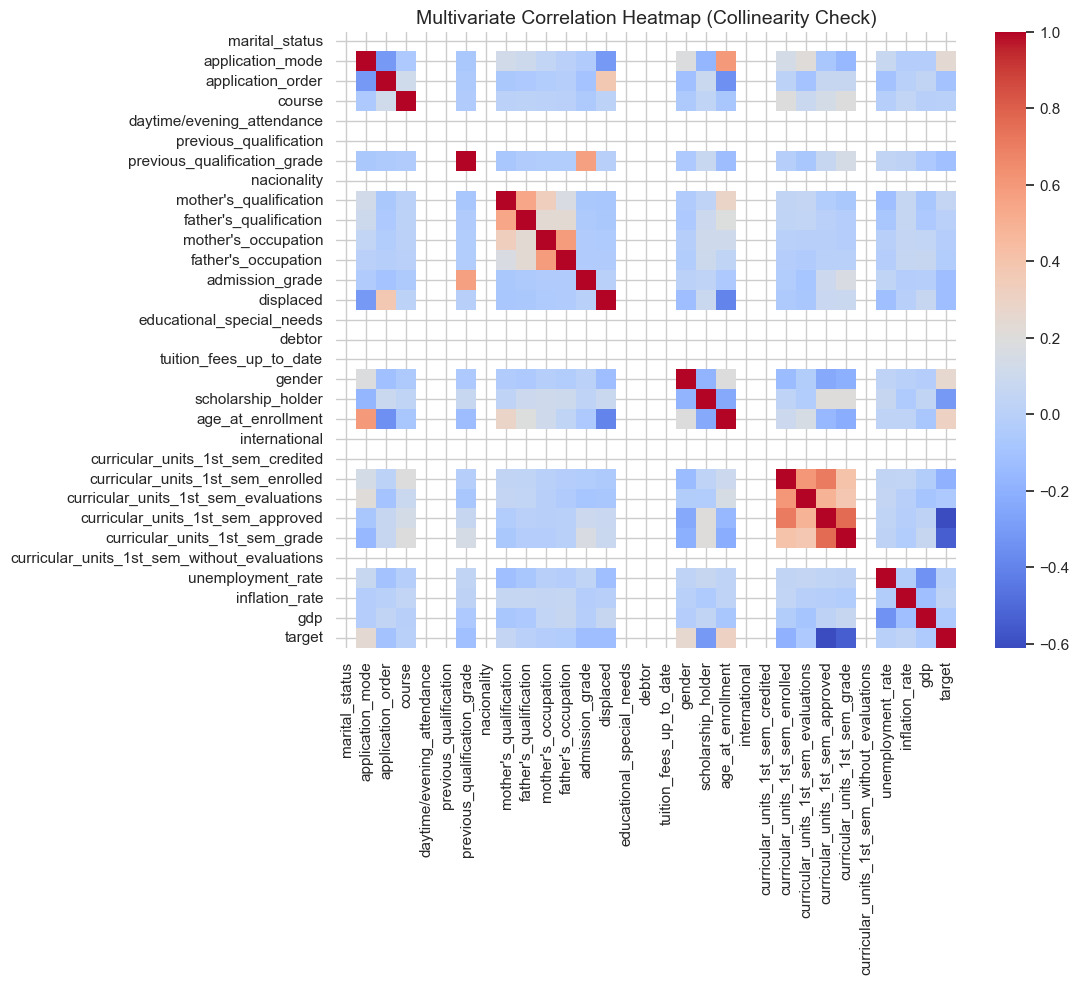

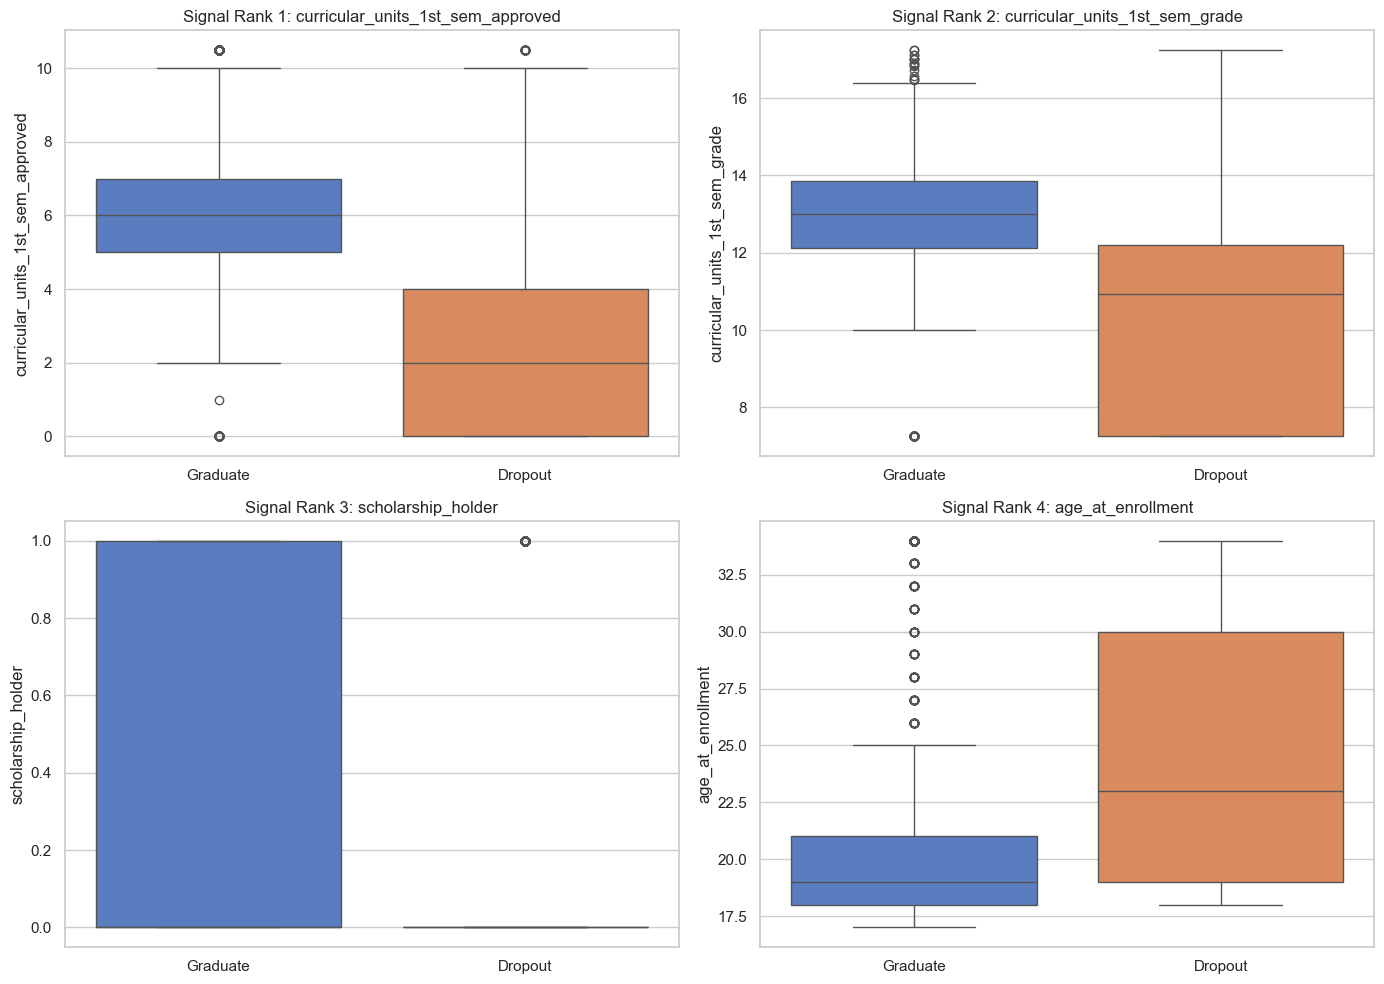

In [5]:
# Generate a correlation matrix to assess relationships between predictive features and the target variable.
corr_matrix = df_historical[numeric_cols + ['target']].corr()

# Extract the top four features that possess the strongest absolute correlation with student attrition.
target_corr = corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)
top_features = target_corr.head(4).index.tolist()

# Visualize a correlation heatmap to detect multicollinearity among the predictor variables.
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Multivariate Correlation Heatmap (Collinearity Check)', fontsize=14)
plt.show()

# Plot the distributions of the strongest predictors to visually confirm how well they separate graduates from dropouts.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.boxplot(
        data=df_historical, 
        x='target', 
        y=feature, 
        palette='muted', 
        ax=axes[i],
        hue='target',
        legend=False
    )
    axes[i].set_title(f'Signal Rank {i+1}: {feature}', fontsize=12)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Graduate', 'Dropout'])
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

## 5. Preprocessing Architecture: Handling Collinearity and Scaling

With the historical ground truth isolated, my next step is to build the data preprocessing architecture. 

During the Exploratory Data Analysis, the correlation heatmap warned me of potential multicollinearity among the academic predictor variables. To eliminate visual bias, I ran a programmatic check on the correlation matrix using a strict 0.75 threshold. This revealed a single pair of highly redundant features: `curricular_units_1st_sem_approved` and `curricular_units_1st_sem_grade` (Pearson correlation of 0.762). Because these two variables contain effectively the same information, keeping both would destabilize the weights of my linear models. Guided by my EDA boxplots, which proved `approved` units carry the strongest mathematical signal for retention, I systematically dropped the `grade` feature.

To build a professional and leak-proof pipeline, I utilized a Scikit-Learn `ColumnTransformer`. This ensures that all numerical variables are standardized (`StandardScaler`) and all categorical variables are mapped into binary matrices (`OneHotEncoder`) simultaneously, preventing any data from the test set from leaking into the training transformations.

In [6]:
# Eliminate multicollinearity by dropping the redundant feature identified during the programmatic EDA check.
df_historical = df_historical.drop(columns=['curricular_units_1st_sem_grade'])

# Isolate the predictor features from the target variable using the cleaned historical dataset.
X_hist = df_historical.drop(columns=['target'])
y_hist = df_historical['target']

# Define categorical variables based on the dataset dictionary for proper encoding.
cat_vars = ['marital_status', 'application_mode', 'application_order', 'course', 
            'daytime/evening_attendance', 'previous_qualification', 'nacionality', 
            "mother's_qualification", "father's_qualification", "mother's_occupation", 
            "father's_occupation", 'displaced', 'educational_special_needs', 
            'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'international']

# Cast categorical integer codes to strings to ensure the encoder treats them as discrete categories, not math.
for col in cat_vars:
    X_hist[col] = X_hist[col].astype(str)

# Dynamically extract the remaining continuous variables to route them to the standard scaler.
num_vars = [col for col in X_hist.columns if col not in cat_vars]

# Perform a stratified train-test split to strictly preserve the 60/40 target class imbalance.
X_train, X_test, y_train, y_test = train_test_split(
    X_hist, y_hist, test_size=0.2, random_state=42, stratify=y_hist
)

# Bundle the mathematical transformations into a single preprocessor engine to prevent data leakage.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_vars),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_vars)
    ])

## 6. Predictive Modeling & Hyperparameter Tuning

With the collinearity addressed and the preprocessing architecture locked in, I moved to the modeling phase. I trained the algorithms strictly on the binary historical training set to capture the pure signal of student attrition. 

My approach was to compare three distinct architectures to see which mathematical approach best mapped the problem:

1. **LASSO Logistic Regression:** A regularized linear model using an L1 penalty. I included this because it performs automatic feature selection, resulting in a highly interpretable model for non-technical business stakeholders. 
2. **Random Forest Classifier:** A bagging ensemble method that builds hundreds of independent decision trees to capture complex, non-linear student risk profiles.
3. **Gradient Boosting Classifier:** A sequential tree approach where each tree is built specifically to correct the mathematical errors of the previous tree.

I applied balanced class weights to ensure the algorithms did not ignore the minority class (Dropouts). Finally, I optimized the hyperparameters for all three models using 5-fold Cross-Validation (`GridSearchCV`). To extract the absolute maximum performance from the 1st-semester data without wasting compute time, the grids below reflect a fine-tuned search centered on the optimal parameters discovered during an initial coarse search.

In [ ]:
# Construct the LASSO pipeline and define a fine-tuned grid around the coarse winner (C=0.8).
lasso_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=42, max_iter=2000))
])
lasso_params = {'lasso__C': [0.6, 0.8, 1.0]}
lasso_grid = GridSearchCV(lasso_pipe, lasso_params, cv=5, scoring='balanced_accuracy')

display(Markdown("**Tuning LASSO Logistic Regression...**"))
lasso_grid.fit(X_train, y_train)

# Construct the Random Forest pipeline with a tight grid centered on 100 trees and a depth of 10.
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))
])
rf_params = {
    'rf__n_estimators': [80, 100, 120],
    'rf__max_depth': [8, 10, 12],
    'rf__min_samples_split': [2, 3, 4]
}
rf_grid = GridSearchCV(rf_pipe, rf_params, cv=5, scoring='balanced_accuracy', n_jobs=-1)

display(Markdown("**Tuning Random Forest Classifier...**"))
rf_grid.fit(X_train, y_train)

# Construct the Gradient Boosting pipeline, fine-tuning the learning rate around 0.10 and depth around 3.
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('gb', GradientBoostingClassifier(random_state=42))
])
gb_params = {
    'gb__n_estimators': [80, 100, 120],
    'gb__learning_rate': [0.05, 0.10, 0.15],
    'gb__max_depth': [2, 3, 4]
}
gb_grid = GridSearchCV(gb_pipe, gb_params, cv=5, scoring='balanced_accuracy', n_jobs=-1)

display(Markdown("**Tuning Gradient Boosting Classifier...**"))
gb_grid.fit(X_train, y_train)

# Output the final validated scores
cv_results = pd.DataFrame({
    'Algorithm': ['LASSO', 'Random Forest', 'Gradient Boosting'],
    'Best Balanced Accuracy': [lasso_grid.best_score_, rf_grid.best_score_, gb_grid.best_score_],
    'Optimal Parameters': [str(lasso_grid.best_params_), str(rf_grid.best_params_), str(gb_grid.best_params_)]
})
display(cv_results.style.set_caption("FINAL VALIDATION SCORES").format({'Best Balanced Accuracy': '{:.4f}'}).hide(axis='index'))

Tuning LASSO Logistic Regression...
Tuning Random Forest Classifier...
Tuning Gradient Boosting Classifier...


Algorithm,Best Balanced Accuracy,Optimal Parameters
LASSO,0.8518,{'lasso__C': 0.8}
Random Forest,0.8388,"{'rf__max_depth': 12, 'rf__min_samples_split': 3, 'rf__n_estimators': 120}"
Gradient Boosting,0.8471,"{'gb__learning_rate': 0.05, 'gb__max_depth': 4, 'gb__n_estimators': 100}"


## 7. Model Evaluation

After tuning the hyperparameters, I evaluated the three models on the unseen test data. For an early intervention system, the primary metric is recall for the dropout class. 

Recall measures the ability to correctly identify students who will eventually drop out. Missing an at-risk student has a high cost. I am willing to accept some false positives (flagging a student who ultimately graduates) because scheduling an unnecessary advising meeting is a low-cost intervention. 

I evaluated each model against the test set to determine which one maximized dropout recall while maintaining a stable balanced accuracy.

In [8]:
# Evaluate all tuned models on the unseen test set to compare generalization.
models = {
    'LASSO Logistic Regression': lasso_grid,
    'Random Forest': rf_grid,
    'Gradient Boosting': gb_grid
}

# Calculate balanced accuracy and dropout recall for each model.
results = []
for name, model in models.items():
    preds = model.predict(X_test)
    bal_acc = balanced_accuracy_score(y_test, preds)
    dropout_recall = recall_score(y_test, preds, pos_label=1)
    results.append({'Model': name, 'Balanced Accuracy': bal_acc, 'Dropout Recall': dropout_recall})

# Format the performance metrics into a clean table for comparison.
results_df = pd.DataFrame(results).sort_values(by='Dropout Recall', ascending=False)
display(results_df.style.format({'Balanced Accuracy': '{:.4f}', 'Dropout Recall': '{:.4f}'}).hide(axis='index'))

Model,Balanced Accuracy,Dropout Recall
LASSO Logistic Regression,0.8518,0.8415
Random Forest,0.8415,0.8028
Gradient Boosting,0.8521,0.7993


### 7.1 Final Model Selection and Feature Impact

Gradient Boosting and LASSO achieved nearly identical balanced accuracy scores. LASSO performed significantly better on the primary metric, successfully identifying 84.15% of the actual dropouts in the test set. 

I selected LASSO as the final model for deployment. Because it is a regularized linear model, it provides high interpretability. I extracted the model coefficients to determine which student features carry the most weight. This allows the university to understand exactly what drives student attrition, rather than just receiving a black-box prediction.

,precision,recall,f1-score,support
Graduate,0.894000,0.862000,0.878000,442.000000
Dropout,0.797000,0.842000,0.818000,284.000000
accuracy,0.854000,0.854000,0.854000,0.854000
macro avg,0.846000,0.852000,0.848000,726.000000
weighted avg,0.856000,0.854000,0.855000,726.000000


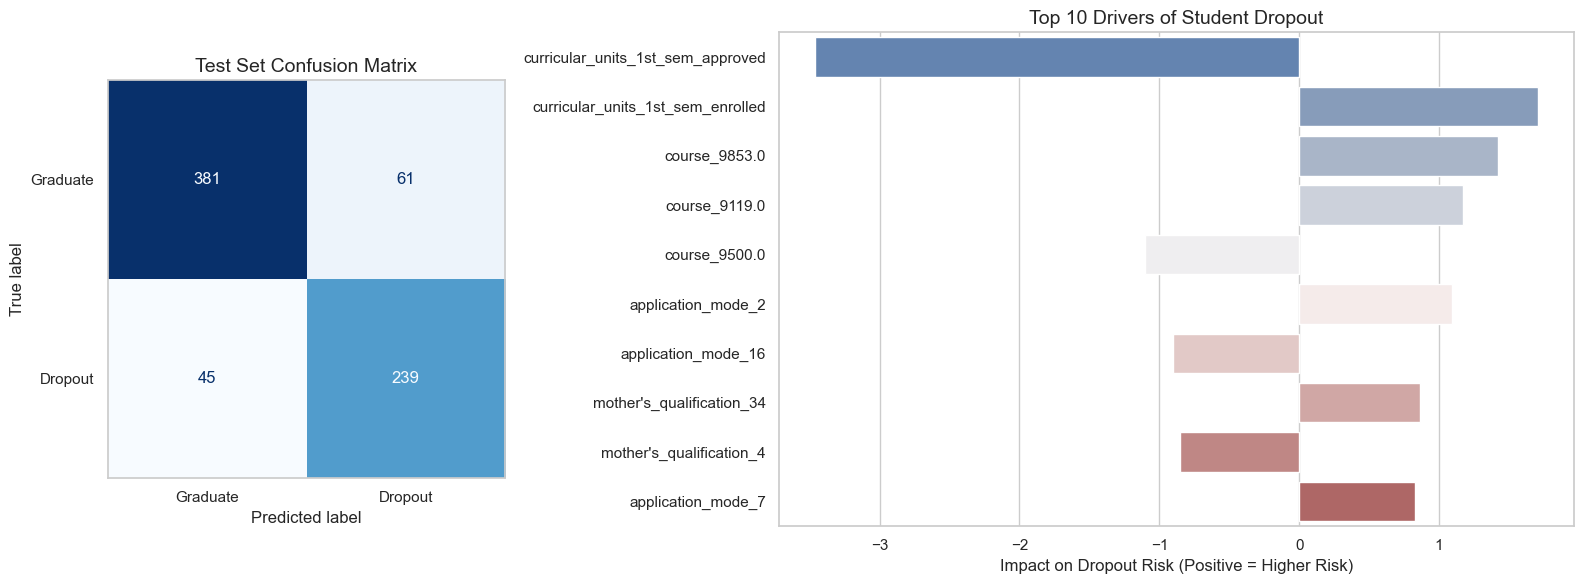

In [9]:
# Isolate the final LASSO model and its feature names to interpret the results.
final_model = lasso_grid.best_estimator_
lasso_step = final_model.named_steps['lasso']
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

# Generate final predictions to evaluate specific class performance.
lasso_preds = final_model.predict(X_test)

report_dict = classification_report(y_test, lasso_preds, target_names=['Graduate', 'Dropout'], output_dict=True)
display(pd.DataFrame(report_dict).T.round(3).style.set_caption("FINAL MODEL: LASSO LOGISTIC REGRESSION"))

# Map the model coefficients to their original feature names.
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': lasso_step.coef_[0]})
coef_df['Feature'] = coef_df['Feature'].str.replace('num__', '').str.replace('cat__', '')

# Extract the top 10 features with the highest absolute impact on the prediction.
top_features = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index).head(10).copy()

# Set up a side-by-side visual to display the confusion matrix and the feature impact.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 2]})

# Plot the confusion matrix to show the exact breakdown of true and false predictions.
ConfusionMatrixDisplay.from_predictions(
    y_test, lasso_preds, 
    display_labels=['Graduate', 'Dropout'], 
    cmap='Blues', 
    ax=axes[0], 
    colorbar=False
)
axes[0].set_title('Test Set Confusion Matrix', fontsize=14)
axes[0].grid(False)

# Plot the top dropout drivers to communicate the risk factors to stakeholders.
sns.barplot(data=top_features, x='Coefficient', y='Feature', palette='vlag', ax=axes[1], hue='Feature', legend=False)
axes[1].set_title('Top 10 Drivers of Student Dropout', fontsize=14)
axes[1].set_xlabel('Impact on Dropout Risk (Positive = Higher Risk)', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 8. Live Deployment: Generating the Intervention List

The final stage of the project transitions the model from testing to deployment. I applied the trained LASSO model to the `Enrolled` cohort, which consists of students whose final outcomes are not yet determined. 

Instead of generating a simple binary prediction, I configured the model to output a continuous risk probability based strictly on 1st-semester data. To make this actionable for academic advisors with limited time, I converted these raw probabilities into relative percentile ranks and grouped them into capacity-based triage tiers. This creates a prioritized call list, ensuring intervention resources are directed toward the highest-risk students first.

In [10]:
# Isolate the predictor variables for the currently enrolled student cohort.
X_live = df_live.drop(columns=['target'])

# Cast categorical variables to strings to ensure compatibility with the pipeline's encoder.
for col in cat_vars:
    X_live[col] = X_live[col].astype(str)

# Calculate the continuous risk probability of dropping out for each active student.
df_live['raw_risk_score'] = final_model.predict_proba(X_live)[:, 1]

# Convert raw probabilities into percentile ranks to easily compare active students against each other.
df_live['risk_percentile'] = df_live['raw_risk_score'].rank(pct=True) * 100

# Define capacity-based triage tiers so academic advisors can prioritize their outreach.
def assign_percentile_tier(percentile):
    if percentile >= 90:
        return "Tier 1: Top 10% Risk (Immediate Action)"
    elif percentile >= 75:
        return "Tier 2: Top 25% Risk (Email & Advisor Meeting)"
    elif percentile >= 50:
        return "Tier 3: Above Average Risk (Watchlist)"
    else:
        return "Tier 4: Below Average Risk (Safe)"

# Apply the triage logic to assign a specific intervention tier to every active student.
df_live['intervention_tier'] = df_live['risk_percentile'].apply(assign_percentile_tier)

# Sort the students from highest to lowest risk to create an actionable call list.
report_columns = ['raw_risk_score', 'risk_percentile', 'intervention_tier']
intervention_list = df_live[report_columns].sort_values(by='risk_percentile', ascending=False)

# Display the top 10 most at-risk students for immediate review.
display(intervention_list.head(10).style.set_caption("TOP 10 AT-RISK STUDENTS (DECEMBER DEPLOYMENT)").format({'raw_risk_score': '{:.4f}', 'risk_percentile': '{:.2f}'}).hide(axis='index'))

# Export the final prioritized list for the university's academic advising team.
intervention_list.to_csv('december_intervention_list.csv')

raw_risk_score,risk_percentile,intervention_tier
0.9995,100.00,Tier 1: Top 10% Risk (Immediate Action)
0.9993,99.87,Tier 1: Top 10% Risk (Immediate Action)
0.9993,99.75,Tier 1: Top 10% Risk (Immediate Action)
0.9992,99.62,Tier 1: Top 10% Risk (Immediate Action)
0.9989,99.50,Tier 1: Top 10% Risk (Immediate Action)
0.9989,99.37,Tier 1: Top 10% Risk (Immediate Action)
0.9989,99.24,Tier 1: Top 10% Risk (Immediate Action)
0.9988,99.12,Tier 1: Top 10% Risk (Immediate Action)
0.9987,98.99,Tier 1: Top 10% Risk (Immediate Action)
0.9986,98.87,Tier 1: Top 10% Risk (Immediate Action)


## 9. Strategic Recommendations and Limitations

I selected LASSO as the final deployment model because interpretability is required for this tool to be adopted. If an algorithm flags a student as high-risk, academic advisors need to know exactly why so they can initiate the right conversation. A black-box model cannot provide that context.

Based on the top dropout drivers mathematically identified by the model, I recommend three immediate advising strategies for the Tier 1 students:
* **Academic Intervention:** Students failing first-semester classes should be automatically enrolled in peer mentorship or early tutoring programs.
* **Financial Routing:** Students flagged for unpaid tuition should be proactively routed to financial aid counselors to explore emergency grants or structured payment plans.
* **Non-Traditional Student Support:** Older age at enrollment is a major risk factor. The university should evaluate its support systems for working adults, such as offering more evening classes or childcare resources.

### Model Limitations
This early-warning system has distinct operational and data limitations. First, predicting a multi-year academic outcome using only a single semester of data introduces irreducible error. If a student performs perfectly in their first semester but drops out in their third year due to an unforeseen life event, an early-warning model cannot mathematically predict that outcome. This issue is compounded because the original dataset lacks temporal markers indicating exactly when a student enrolled, graduated, or dropped out. Without knowing if a student left in semester two or semester eight, the model is forced to treat all attrition equally, which slightly dilutes the specific early-warning signals.

Second, the intervention triage tiers are currently hardcoded to arbitrary percentiles. If a university has 5,000 students and only three advisors, flagging the top 10% (500 students) for immediate action is not practical. Before deployment, these percentile cutoffs must be dynamically adjusted to match the actual budget and headcount capacity of the academic advising department.

### Methodological Reflection
A close inspection of the macroeconomic variables (inflation, GDP) shows that this dataset blends students from multiple incoming years. This is a major modeling advantage. Training on a single cohort risks overfitting to the anomalies of one specific year. By evaluating a mixed timeframe, the model filters out temporary economic noise and locks onto the timeless, universal indicators of student attrition. 

My core architectural decision was to drop all late-stage academic data. Building a highly accurate model using second-semester or second-year grades is mathematically easy, but it operates like an autopsy report. By strictly constraining the inputs to first-semester performance, this pipeline trades a small percentage of raw accuracy for a five-month operational head start, delivering an actionable business tool rather than just a theoretical academic exercise.

### Future Work
If given the opportunity to expand this system, I would integrate behavioral data rather than relying entirely on static demographics and grades. Adding Learning Management System (Canvas) login frequency, campus card swipe data for dining halls and residence halls to measure social engagement, and first-generation college status would allow the model to detect social isolation and disengagement weeks before a student actually fails a test. 

To solve the temporal blind spots identified in my limitations, I would also require exact timestamps recording the specific month and year a student drops out or graduates. This would allow me to build a dynamic time-series model that tracks risk at different stages of a degree. Finally, integrating financial aid dependencies and academic advising attendance records would provide a complete mathematical picture of a student's institutional support.